In [46]:
import tensorflow as tf
import tensorflow_probability as tfp 
import tensorflow_addons as tfa
from tensorflow import keras

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest

import numpy as np
import pandas as pd
import functions
from Models.LSTM_VAE import LSTM_VAE
from Models.LSTM_AE import LSTM_AE
from Models.DAGMM import DAGMM_AE
from Models.USAD import USAD_MTS
from Models.COUTA import COUTA
from Models.CTAD import CTAD
from Models.LSTM_CBCL import LSTM_CBCL
from Models.Sklearn_models import PCA_AE_for_MTS, IsolationForest_MTS

import ast, os, gc, shutil, math
import pickle
import ctypes


In [47]:
# 1. TensorFlow version
print("TF version:", tf.__version__)

# 2. Is this a GPU build?
print("Built with CUDA:", tf.test.is_built_with_cuda())

# 3. Any GPUs visible?
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("Could not set memory growth:", e)


TF version: 2.10.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [48]:
WINDOW_SIZE = 10
STRIDE = 1
LATENT_DIM = 10
LSTM_H_DIM = 64
DROPOUT_RATE = 0.2
KL_BETA = 1.0
KERNEL_REGULARIZER = keras.regularizers.L2(1e-4)
SMALL=64
MED=128
LARGE=256
XLARGE=512
XXLARGE=1024
EPOCHS = 100
LEARNING_RATE = 3e-4
CLIPNORM = 10.0
EARLY_STOP_PATIENCE = 5

PCA_COMP = 10
IF_ESTIMATORS=300

# COUTA PARAM
COUTA_DIMS = [16]
COUTA_EMB_DIM = 16

# CTAD PARAM
CTAD_LSTM=64
CTAD_PROJECTION_HU=128
CTAD_LATENT_DIM=32
                
                
LSTM_CBCL_HIDDEN_UNITS = 64
NUM_LAYERS=2
LSTM_LATENT_DIM=16
BOTTLENECK=True 
MLP_HU=128
REP_DIM=128

In [49]:
class ModelGenerator():
    @staticmethod
    def get_PCA_AE(n_components=PCA_COMP, window_size=WINDOW_SIZE, use_incremental=False):
        return PCA_AE_for_MTS(n_components=n_components, window_size=window_size, use_incremental=use_incremental)
    
    @staticmethod
    def get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42):
        return IsolationForest_MTS(n_estimators=n_estimators, max_samples=max_samples, contamination=contamination, random_state=random_state)
    
    @staticmethod
    def get_LSTM_AE(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size=MED):
        LSTM_AE_model = LSTM_AE(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size=batch_size)
        LSTM_AE_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                              loss_fn=keras.losses.MeanSquaredError(), 
                              clipnorm=CLIPNORM, 
                              early_stop_patience=EARLY_STOP_PATIENCE)
        return LSTM_AE_model
    
    @staticmethod
    def get_LSTM_VAE(timesteps=WINDOW_SIZE, n_features=None, lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED):
        LSTM_VAE_model = LSTM_VAE(timesteps=timesteps, n_features=n_features, lstm_h_dim=lstm_h_dim, latent_dim=latent_dim, 
                                  dropout_rate=DROPOUT_RATE, kl_beta=KL_BETA, batch_size=batch_size)
        LSTM_VAE_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                               clipnorm=CLIPNORM, 
                               early_stop_patience=EARLY_STOP_PATIENCE)
        return LSTM_VAE_model
    
    @staticmethod
    def get_DAGMM(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size=LARGE):
        DAGMM_model = DAGMM_AE(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size=batch_size)
        DAGMM_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), clipnorm=CLIPNORM, early_stop_patience=EARLY_STOP_PATIENCE)
        return DAGMM_model
        
    @staticmethod
    def get_USAD(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size = MED):
        USAD_model = USAD_MTS(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size = batch_size)
        USAD_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), clipnorm=CLIPNORM, early_stop_patience=EARLY_STOP_PATIENCE)
        return USAD_model
        
    @staticmethod
    def get_COUTA(input_dim=None, hidden_dims=[16], emb_dim = 16, dropout_rate=DROPOUT_RATE, batch_size=SMALL):
        couta_model = COUTA(input_dim=input_dim, hidden_dims=hidden_dims, emb_dim = emb_dim, dropout_rate=dropout_rate, batch_size=batch_size)
        couta_model.compile(keras.optimizers.Adam(learning_rate=LEARNING_RATE))
        return couta_model
    
    @staticmethod
    def get_CTAD(lstm_units=64, projection_hu=128, latent_dim=32, kernel_regularizer=None, dropout_rate=0.0,
                 batch_size=512, clip_val=1, patience =5, score='l2', aug_params={}):
        ctad_model = CTAD(lstm_units=lstm_units, projection_hu=projection_hu, latent_dim=latent_dim, kernel_regularizer=kernel_regularizer, dropout_rate=dropout_rate,
                 batch_size=batch_size, clip_val=clip_val, patience = patience, score=score)
        ctad_model.compile(tf.optimizers.Adam(learning_rate=1e-4))
        ctad_model.set_aug_params(nv_pos1=aug_params["nv_pos1"], nv_pos2=aug_params["nv_pos2"], nv_neg1=aug_params["nv_neg1"], nv_neg2=aug_params["nv_neg2"], 
                                p_pos1=aug_params["p_pos1"], p_pos2=aug_params["p_pos2"], p_neg1=aug_params["p_neg1"], p_neg2=aug_params["p_neg2"],
                                noise_sigma=aug_params["noise_sigma"], bias=aug_params["bias"], amp=aug_params["amp"])
        return ctad_model
    
    @staticmethod
    def get_LSTM_CBCL(timesteps=WINDOW_SIZE, n_features = None, latent_dim=LATENT_DIM, num_layers=2, bottleneck=True, 
                    hidden_units = 64, dropout_rate=0.2, kernel_regularizer=False, batch_size=512, patience=5, recurrent_regularizer=True, MLP_hu=MLP_HU, rep_dim=REP_DIM, aug_params={}):
        LSTM_CBCL_model = LSTM_CBCL(timesteps=timesteps, n_features = n_features, latent_dim=latent_dim, num_layers=num_layers, bottleneck=bottleneck, 
                                hidden_units = hidden_units, dropout_rate=dropout_rate, kernel_regularizer=kernel_regularizer, batch_size=batch_size, 
                                patience=patience, recurrent_regularizer=recurrent_regularizer, MLP_hu=MLP_hu, rep_dim=rep_dim)
        LSTM_CBCL_model.compile(tfa.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5))
        LSTM_CBCL_model.set_aug_params(nv_pos1=aug_params["nv_pos1"], nv_pos2=aug_params["nv_pos2"], nv_neg1=aug_params["nv_neg1"], nv_neg2=aug_params["nv_neg2"], 
                                p_pos1=aug_params["p_pos1"], p_pos2=aug_params["p_pos2"], p_neg1=aug_params["p_neg1"], p_neg2=aug_params["p_neg2"],
                                noise_sigma=aug_params["noise_sigma"], bias=aug_params["bias"], amp=aug_params["amp"])
        return LSTM_CBCL_model

In [ ]:
def run_models(models, train_ds, test_ds, y_true:np.ndarray, epochs=50, verbose=1, use_timestamp_level=False, use_point_adjust=False, stride=STRIDE, frame=WINDOW_SIZE):
    preds = {}
    anom_scores = {}
    expected_anom_ratio = y_true.sum() / len(y_true)
    for model_name, model in models.items():
        print(f"\t\tTraining: {model_name}")
        if isinstance(model, (LSTM_AE, LSTM_VAE, DAGMM_AE, USAD_MTS, COUTA, CTAD, LSTM_CBCL)):
            model.fit_manual(train_ds, epochs=epochs, verbose=verbose)
            anom_score = model.score(test_ds)
        elif isinstance(model, (PCA_AE_for_MTS, IsolationForest_MTS)):
            model.fit(train_ds)
            anom_score = model.score(test_ds)['anomaly_score']
        else: 
            break
        
        if use_timestamp_level:
            scores = functions.timestamp_score_maxpooling(anom_score, stride=stride, n_timestamps=len(y_true), frame_length=frame)
            anom_scores[model_name] = scores
            preds[model_name] = (scores > np.percentile(scores, (1.0-expected_anom_ratio)*100)).astype(int)
            if use_point_adjust:
                if isinstance(y_true, pd.Series):
                    y_true = y_true.to_numpy()
                preds[model_name] = functions.point_adjust(y_true=y_true.reshape([-1]), y_pred=preds[model_name])
        else:
            anom_scores[model_name] = anom_score
            y_preds = (anom_score > np.percentile(anom_score, (1.0-expected_anom_ratio)*100)).astype(int)
            preds[model_name] = y_preds

    tf.keras.backend.clear_session()
    gc.collect()
    return preds, anom_scores

def train_baselines_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_baselines_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # BASELINES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=True)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:   
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_baselines_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # BASELINES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_baselines_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_SMD(server, m, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, 
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_COUTA_PSM(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, lazy=True, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_PSM_windows(mm_clip_scaler, window_size=window_size, frame_step=frame_step, lazy=lazy)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=STRIDE, frame=WINDOW_SIZE)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_SMAP_MSL(rover, sys, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_WADI(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_WADI_windows(mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                    batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.5, "amp":2
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, 
                                                verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_CTAD_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: 
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=True)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                            batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.5, "amp":2
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                    batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.2, "amp":1.5
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                            batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='cosine',
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.1, "amp":1.5,
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except  tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue


def train_LSTM_CBCL_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=2, bottleneck=BOTTLENECK, 
                                                    hidden_units = 64, dropout_rate=0.2, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=128, rep_dim=128,
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.5, "amp": 1.5
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels

        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_LSTM_CBCL_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, lazy=True, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=lazy)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=NUM_LAYERS, bottleneck=BOTTLENECK, 
                                                          hidden_units = 128, dropout_rate=0.1, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=64, rep_dim=32,
                                                          aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.7, "amp": 1.5
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels

        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_LSTM_CBCL_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=NUM_LAYERS, bottleneck=BOTTLENECK, 
                                                    hidden_units = LSTM_CBCL_HIDDEN_UNITS, dropout_rate=0.1, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=MLP_HU, rep_dim=REP_DIM,
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.8, "amp": 1.5
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels

        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_LSTM_CBCL_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=NUM_LAYERS, bottleneck=BOTTLENECK, 
                                                          hidden_units = LSTM_CBCL_HIDDEN_UNITS, dropout_rate=0.1, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=128, rep_dim=128,
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.2, "amp": 1.5,
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def clear_memory(*args):
    for var in args:
        del var
    tf.keras.backend.clear_session()
    gc.collect()

def run_results(use_timestamp_level=False, use_point_adjust=False, verbose=0, run_SMD=True, run_PSM=True, run_SMAP_MSL=True, run_WADI=True):
    F1_scores = {"SMD": {}, "PSM": {}, "SMAP": {}, "MSL": {}, "WADI": {}}
    roc_scores = {"SMD": {}, "PSM": {}, "SMAP": {}, "MSL": {}, "WADI": {}}
    precision_scores = {"SMD": {}, "PSM": {}, "SMAP": {}, "MSL": {}, "WADI": {}}
    recall_scores = {"SMD": {}, "PSM": {}, "SMAP": {}, "MSL": {}, "WADI": {}}
    if run_SMD:
        print ('Testing models on SMD dataset:')
        smd_combos = {1:[1,2,5,6], 2:[1,7], 3:[11]}
        for server, machines in smd_combos.items():
            for m in machines:
                tf.keras.backend.clear_session()
                print (f"\t Server {server} - Machine {m}")
                std_scaler = StandardScaler()
                mm_scaler = MinMaxScaler()
                mm_clip_scaler = functions.MinMaxClippingScaler(4)
                lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_SMD(server, m, mm_scaler, window_size=5, frame_step=1, 
                                                        use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                preds, anom_scores, test_labels = train_baselines_SMD(server, m, std_scaler, window_size=5, frame_step=STRIDE, 
                                                        use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #couta_preds, couta_scores, test_labels = train_COUTA_SMD(server, m, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                #                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #ctad_preds, ctad_scores, test_labels = train_CTAD_SMD(server, m, mm_scaler, window_size=4, frame_step=STRIDE, 
                #                                         use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                
                #preds['COUTA'] = couta_preds['COUTA']
                #anom_scores['COUTA'] = couta_scores['COUTA']
                #preds['CTAD'] = ctad_preds['CTAD']
                #anom_scores['CTAD'] = ctad_scores['CTAD']
                preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
                anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
                
                lstm_preds, lstm_scores = None, None
                clear_memory(lstm_preds, lstm_scores, std_scaler, mm_scaler)

                metrics = functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_f1-bar.png')
                # metrics = {model: {"f1": f1, "precision": p, "recall": r}}
                functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_pr-bar.png')
                functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_pr-graph.png')
                functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_roc-bar.png')
                roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_roc-graph.png')
                for model in metrics.keys():
                    if model not in F1_scores["SMD"]:
                        F1_scores["SMD"][model] = []
                        roc_scores["SMD"][model] = []
                        precision_scores["SMD"][model] = []
                        recall_scores["SMD"][model] = []
                    F1_scores["SMD"][model].append(metrics[model]["f1"])
                    roc_scores["SMD"][model].append(roc_score[model])
                    precision_scores["SMD"][model].append(metrics[model]["precision"])
                    recall_scores["SMD"][model].append(metrics[model]["recall"])
                    
                clear_memory(preds, anom_scores, test_labels, metrics, roc_score)

    if run_PSM: 
        print ("Testing models on PSM dataset:")
        std_scaler = StandardScaler()
        mm_scaler = MinMaxScaler()
        mm_clip_scaler = functions.MinMaxClippingScaler(4)
        preds, anom_scores, test_labels = train_baselines_PSM(std_scaler, window_size=5, frame_step=STRIDE, 
                                                use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        #couta_preds, couta_scores, test_labels = train_COUTA_PSM(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
        #                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        #ctad_preds, ctad_scores, test_labels = train_CTAD_PSM(mm_scaler, window_size=4, frame_step=STRIDE, 
        #                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_PSM(mm_scaler, window_size=5, frame_step=1, lazy=True, 
                                                use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        #preds['COUTA'] = couta_preds['COUTA']
        #anom_scores['COUTA'] = couta_scores['COUTA'] 
        #preds['CTAD'] = ctad_preds['CTAD']
        #anom_scores['CTAD'] = ctad_scores['CTAD']
        preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
        anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
        
        lstm_preds, lstm_scores = None, None
        clear_memory(lstm_preds, lstm_scores, std_scaler, mm_scaler)
        
        metrics = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Comparisons/PSM/f1-bar.png')
        functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/pr-bar.png')
        functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/pr-graph.png')
        functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/roc-bar.png')
        roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/roc-graph.png')
        for model in metrics.keys():
            F1_scores["PSM"][model]= [metrics[model]["f1"]]
            roc_scores["PSM"][model] = [roc_score[model]]
        clear_memory(preds, anom_scores, test_labels, metrics, roc_score)
    
    if run_SMAP_MSL:
        print ("Testing models on SMAP_MSL dataset:")
        #SMAP_MSL_combos = {'A':1, 'B':1, 'C':1, 'D':2, 'E':1, 'F':1, 'G':1, 'M': 2, 'P':1, 'R':1, 'S':1, 'T':2}
        """SMAP_combos = {'A':[1,2,3,4,5,6,8,9], 'B':[1], 'D':[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13],
                    'E':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], 'F':[1,2,3], 'G':[1, 2, 3, 4, 6, 7], 
                    'P':[1,2,3,4,7], 'R':[1], 'S':[1], 'T':[1,2,3]}"""
        
        SMAP_combos = {'D':[2, 3, 4, 7, 8, 9],
                    'E':[2, 4, 5, 6, 9, 13],'G':[4], 
                    'P':[3,4], 'R':[1], 'T':[3]}
        MSL_combos = {'C':[2], 'D':[14], 'F':[7], 'P':[11, 14], 'T':[5]}
        #for rover, n_systems in SMAP_MSL_combos.items():
            #for sys in range(1, n_systems+1):
        for rover, systems in SMAP_combos.items():
            for sys in systems:
                print (f"\t SMAP Rover {rover} - Number {sys}")
                std_scaler = StandardScaler()
                mm_scaler = MinMaxScaler()
                mm_clip_scaler = functions.MinMaxClippingScaler(4)
                preds, anom_scores, test_labels = train_baselines_SMAP_MSL(rover, sys, std_scaler, window_size=5, frame_step=STRIDE, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #couta_preds, couta_scores, test_labels = train_COUTA_SMAP_MSL(rover, sys, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                #                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #ctad_preds, ctad_scores, test_labels = train_CTAD_SMAP_MSL(rover, sys, mm_scaler, window_size=4, frame_step=STRIDE, 
                #                                         use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_SMAP_MSL(rover, sys, mm_scaler, window_size=5, frame_step=1, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #preds['COUTA'] = couta_preds['COUTA']
                #anom_scores['COUTA'] = couta_scores['COUTA']
                #preds['CTAD'] = ctad_preds['CTAD']
                #anom_scores['CTAD'] = ctad_scores['CTAD']
                preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
                anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
                lstm_preds, lstm_scores = None, None
                clear_memory(lstm_preds, lstm_scores, std_scaler, mm_scaler)
                
                metrics =functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_f1-bar.png')
                functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-bar.png')
                functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-graph.png')
                functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-bar.png')
                roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-graph.png')
                for model in metrics.keys():
                    if model not in F1_scores["SMAP"]:
                        F1_scores["SMAP"][model] = []
                        roc_scores["SMAP"][model] = []
                        precision_scores["SMAP"][model] = []
                        recall_scores["SMAP"][model] = []
                    F1_scores["SMAP"][model].append(metrics[model]["f1"])
                    roc_scores["SMAP"][model].append(roc_score[model])
                    precision_scores["SMAP"][model].append(metrics[model]["precision"])
                    recall_scores["SMAP"][model].append(metrics[model]["recall"])
                clear_memory(preds, anom_scores, test_labels, metrics, roc_score)

        
        for rover, systems in MSL_combos.items():
            for sys in systems:
                print (f"\t MSL Rover {rover} - Number {sys}")
                std_scaler = StandardScaler()
                mm_scaler = MinMaxScaler()
                mm_clip_scaler = functions.MinMaxClippingScaler(4)
                preds, anom_scores, test_labels = train_baselines_SMAP_MSL(rover, sys, std_scaler, window_size=5, frame_step=STRIDE, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #couta_preds, couta_scores, test_labels = train_COUTA_SMAP_MSL(rover, sys, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                #                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #ctad_preds, ctad_scores, test_labels = train_CTAD_SMAP_MSL(rover, sys, mm_scaler, window_size=4, frame_step=STRIDE, 
                #                                         use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_SMAP_MSL(rover, sys, mm_scaler, window_size=5, frame_step=1, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                #preds['COUTA'] = couta_preds['COUTA']
                #anom_scores['COUTA'] = couta_scores['COUTA']
                #preds['CTAD'] = ctad_preds['CTAD']
                #anom_scores['CTAD'] = ctad_scores['CTAD']
                preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
                anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
                lstm_preds, lstm_scores = None, None
                clear_memory(lstm_preds, lstm_scores, std_scaler, mm_scaler)
            
                metrics =functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_f1-bar.png')
                functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-bar.png')
                functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-graph.png')
                functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-bar.png')
                roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-graph.png')
                for model in metrics.keys():
                    if model not in F1_scores["MSL"]:
                        F1_scores["MSL"][model] = []
                        roc_scores["MSL"][model] = []
                        precision_scores["MSL"][model] = []
                        recall_scores["MSL"][model] = []
                    F1_scores["MSL"][model].append(metrics[model]["f1"])
                    roc_scores["MSL"][model].append(roc_score[model])
                    precision_scores["MSL"][model].append(metrics[model]["precision"])
                    recall_scores["MSL"][model].append(metrics[model]["recall"])
                clear_memory(preds, anom_scores, test_labels, metrics, roc_score)
    
    if run_WADI:              
        print ("Testing models on WADI dataset:")
        std_scaler = StandardScaler()
        mm_scaler = MinMaxScaler()
        mm_clip_scaler = functions.MinMaxClippingScaler(4)
        wadi_frame_l, wadi_stride = 25, 10
        preds, anom_scores, test_labels = train_baselines_WADI(std_scaler, window_size=wadi_frame_l, frame_step=wadi_stride, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        #couta_preds, couta_scores, test_labels = train_COUTA_WADI(mm_clip_scaler, window_size=wadi_frame_l, frame_step=wadi_stride, 
        #                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        #ctad_preds, ctad_scores, test_labels = train_CTAD_WADI(mm_scaler, window_size=4, frame_step=wadi_stride, 
        #                                        use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_WADI(mm_scaler, window_size=4, frame_step=5, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)

        
        #preds['COUTA'] = couta_preds['COUTA']
        #anom_scores['COUTA'] = couta_scores['COUTA']
        #preds['CTAD'] = ctad_preds['CTAD']
        #anom_scores['CTAD'] = ctad_scores['CTAD']
        preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
        anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
        
        lstm_preds, lstm_scores = None, None
        clear_memory(lstm_preds, lstm_scores, std_scaler, mm_scaler)
        
        metrics = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Comparisons/WADI/f1-bar.png')
        functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/pr-bar.png')
        functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/pr-graph.png')
        functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/roc-bar.png')
        roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/roc-graph.png')
        for model in metrics.keys():
            F1_scores["WADI"][model]= [metrics[model]["f1"]]
            roc_scores["WADI"][model] = [roc_score[model]] 
            
        tf.keras.backend.clear_session() 
        gc.collect()
    
    avg_f1s, avg_rocs = {}, {}
    for dataset in F1_scores.keys():
        avg_f1s[dataset]={}
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in F1_scores[dataset].keys():
            avg_f1 = np.mean(F1_scores[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in roc_scores.keys():
        avg_rocs[dataset]={}
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in roc_scores[dataset].keys():
            avg_roc = np.mean(roc_scores[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocs[dataset][model] = avg_roc
    print(F1_scores, precision_scores, recall_scores)
    
    with open("Model Comparisons/Dataset Performance/model_f1.pkl", "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open("Model Comparisons/Dataset Performance/model_rocauc.pkl", "wb") as f:
        pickle.dump(avg_rocs, f)    
    
    functions.visualize_model_results(avg_f1s, avg_rocs, save=True, save_path='Model Comparisons/Dataset Performance/')

In [51]:
def compare_existing_scores(dir='Model Comparisons - Point Adjusted', new_f1s={}, new_rocs={}):
    with open(os.path.join(dir, 'model_f1.pkl'), 'rb') as f:
        avg_f1s = pickle.load(f)
        
    with open(os.path.join(dir, 'model_rocauc.pkl'), 'rb') as f:
        avg_rocauc = pickle.load(f)
    
    for dataset in new_f1s.keys():
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in new_f1s[dataset].keys():
            avg_f1 = np.mean(new_f1s[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in new_rocs.keys():
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in new_rocs[dataset].keys():
            avg_roc = np.mean(new_rocs[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocauc[dataset][model] = avg_roc

    with open(os.path.join(dir, 'model_f1.pkl'), "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open(os.path.join(dir, 'model_rocauc.pkl'), "wb") as f:
        pickle.dump(avg_rocauc, f)    
        
    functions.visualize_model_results(avg_f1s, avg_rocauc, save=True, save_path=dir)
    


In [52]:
def extra_model_results(use_timestamp_level=False, use_point_adjust=False, verbose=0):
    F1_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    roc_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    print ('Testing models on SMD dataset:')
    smd_combos = {1:[1, 5], 2:[3,4], 3:[2,10]}
    for server, machines in smd_combos.items():
        for m in machines:
            print (f"\t Server {server} - Machine {m}")
            scaler = MinMaxScaler()
            proto_preds, proto_scores, test_labels = train_LSTM_CBCL_SMD(server, m, scaler, window_size=4, frame_step=1, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                                
            f1_scores = functions.display_f1_models(test_labels, proto_preds, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_pr-bar.png')
            functions.compare_pr_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMD"]:
                    F1_scores["SMD"][model] = []
                    roc_scores["SMD"][model] = []
                F1_scores["SMD"][model].append(f1_scores[model])
                roc_scores["SMD"][model].append(roc_score[model])
                
            tf.keras.backend.clear_session()
            gc.collect() 
            
    print ("Testing models on PSM dataset:")
    scaler = MinMaxScaler()
    lazy=False
    proto_preds, proto_scores, test_labels = train_LSTM_CBCL_PSM(scaler, window_size=4, frame_step=1, lazy=lazy, 
                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    
    f1_scores = functions.display_f1_models(test_labels, proto_preds, save=True, save_path='Model Logs/LSTM_CBCL/PSM/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/pr-bar.png')
    functions.compare_pr_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["PSM"][model]= [f1_scores[model]]
        roc_scores["PSM"][model] = [roc_score[model]]

    tf.keras.backend.clear_session() 
    gc.collect() 


    print ("Testing models on SMAP_MSL dataset:")
    SMAP_MSL_combos = {'A':1, 'B':1, 'C':1, 'D':2, 'E':1, 'F':1, 'G':1, 'M': 2, 'P':1, 'R':1, 'S':1, 'T':2}
    print("Using window size of 10...")
    for rover, n_systems in SMAP_MSL_combos.items():
        for sys in range(1, n_systems+1):
            print (f"\t Rover {rover} - Number {sys}")
            scaler = MinMaxScaler()
            proto_preds, proto_scores, test_labels = train_LSTM_CBCL_SMAP_MSL(rover, sys, scaler, window_size=4, frame_step=1, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        
            f1_scores =functions.display_f1_models(test_labels, proto_preds, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_pr-bar.png')
            functions.compare_pr_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMAP_MSL"]:
                    F1_scores["SMAP_MSL"][model] = []
                    roc_scores["SMAP_MSL"][model] = []
                F1_scores["SMAP_MSL"][model].append(f1_scores[model])
                roc_scores["SMAP_MSL"][model].append(roc_score[model])

            tf.keras.backend.clear_session() 
            gc.collect() 

                        
    print ("Testing models on WADI dataset:")
    scaler = MinMaxScaler()
    wadi_frame_l, wadi_stride = 25, 10
    proto_preds, proto_scores, test_labels = train_LSTM_CBCL_WADI(scaler, window_size=4, frame_step=5, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)

    f1_scores = functions.display_f1_models(test_labels, proto_preds, save=True, save_path='Model Logs/LSTM_CBCL/WADI/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/pr-bar.png')
    functions.compare_pr_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["WADI"][model]= [f1_scores[model]]
        roc_scores["WADI"][model] = [roc_score[model]]  
        
    tf.keras.backend.clear_session() 
    gc.collect() 

    avg_f1s, avg_rocs = {}, {}
    for dataset in F1_scores.keys():
        avg_f1s[dataset]={}
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in F1_scores[dataset].keys():
            avg_f1 = np.mean(F1_scores[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in roc_scores.keys():
        avg_rocs[dataset]={}
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in roc_scores[dataset].keys():
            avg_roc = np.mean(roc_scores[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocs[dataset][model] = avg_roc

    functions.visualize_model_results(avg_f1s, avg_rocs, save=True, save_path='Model Logs/LSTM_CBCL/Dataset Performance/')
    """ with open("Model Logs/LSTM_CBCL/Dataset Performance/model_f1.pkl", "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open("Model Logs/LSTM_CBCL/Dataset Performance/model_rocauc.pkl", "wb") as f:
        pickle.dump(avg_rocs, f)   """  
    print(avg_f1s, avg_rocs)
    
    return avg_f1s, avg_rocs

Testing models on SMD dataset:
	 Server 1 - Machine 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 1.201801 - val_loss: 0.969408
	 Breakdown: 
	 MSE: 0.075813, Contrastive: 0.619820, Cluster: 0.247793, Hinge: 0.045567
Epoch 2/100 - train_loss: 0.968031 - val_loss: 0.953942
	 Breakdown: 
	 MSE: 0.075093, Contrastive: 0.618531, Cluster: 0.152139, Hinge: 0.075107
Epoch 3/100 - train_loss: 0.932629 - val_loss: 0.933175
	 Breakdown: 
	 MSE: 0.064042, Contrastive: 0.616617, Cluster: 0.112165, Hinge: 0.091971
Epoch 4/100 - train_loss: 0.912415 - val_loss: 0.905451
	 Breakdown: 
	 MSE: 0.052457, Contrastive: 0.611879, Cluster: 0.099292, Hinge: 0.101374
Epoch 5/100 - train_loss: 0.893087 - val_loss: 0.884926
	 Breakdown: 
	 MSE: 0.042794, Contrastive: 0.607040, Cluster: 0.095459, Hinge: 0.101499
Epoch 6/100 - train_loss: 0.877325 - val_loss: 0.869219
	 Breakdown: 
	 MSE: 0.036605, Contrastive: 0.600749, Cluster: 0.092080, Hinge: 0.106167
Epoch 7/100 - train_loss: 0.865700 - val_loss: 0.85958

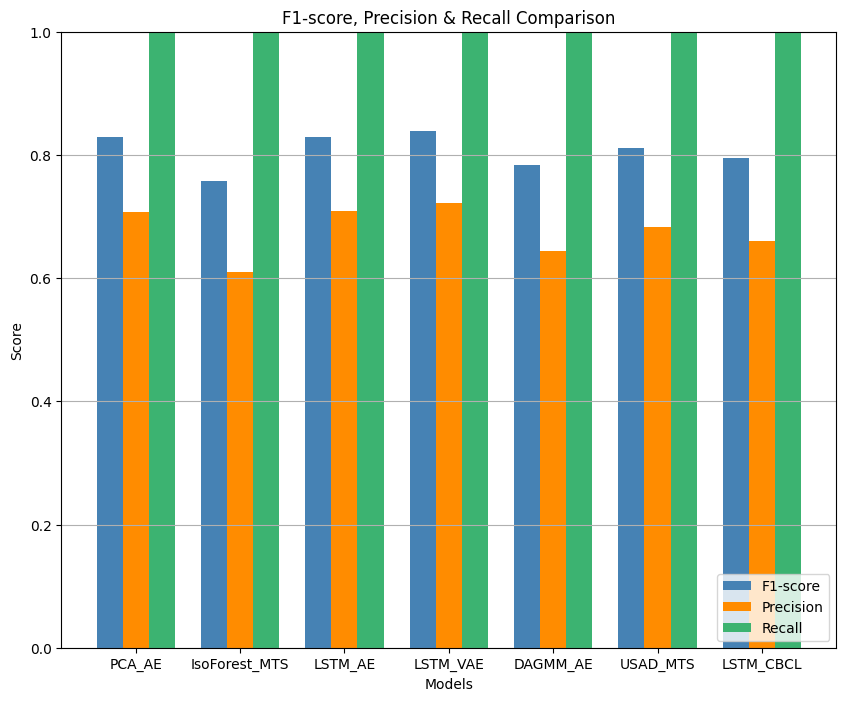

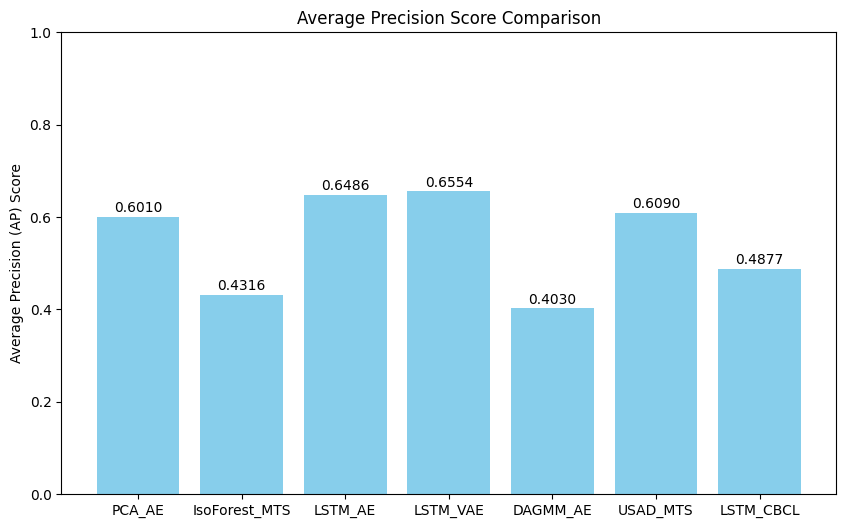

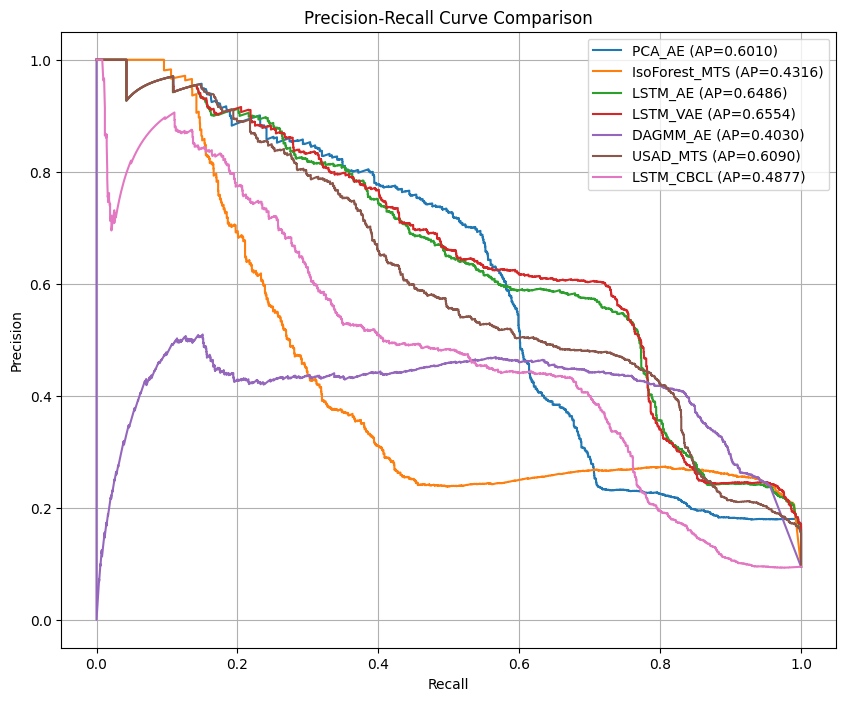

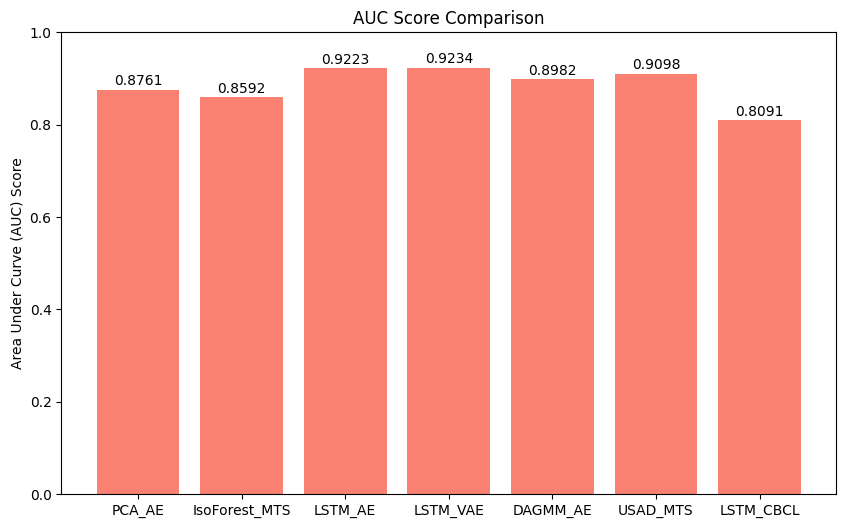

	 Server 1 - Machine 2
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 1.009578 - val_loss: 0.904795
	 Breakdown: 
	 MSE: 0.026916, Contrastive: 0.604051, Cluster: 0.163196, Hinge: 0.079674
Epoch 2/100 - train_loss: 0.896174 - val_loss: 0.891348
	 Breakdown: 
	 MSE: 0.025527, Contrastive: 0.603842, Cluster: 0.106145, Hinge: 0.102144
Epoch 3/100 - train_loss: 0.874138 - val_loss: 0.876797
	 Breakdown: 
	 MSE: 0.022939, Contrastive: 0.594639, Cluster: 0.094836, Hinge: 0.108890
Epoch 4/100 - train_loss: 0.857947 - val_loss: 0.860122
	 Breakdown: 
	 MSE: 0.020840, Contrastive: 0.584614, Cluster: 0.094806, Hinge: 0.109546
Epoch 5/100 - train_loss: 0.842682 - val_loss: 0.845259
	 Breakdown: 
	 MSE: 0.017452, Contrastive: 0.576835, Cluster: 0.088344, Hinge: 0.112552
Epoch 6/100 - train_loss: 0.830201 - val_loss: 0.833757
	 Breakdown: 
	 MSE: 0.014264, Contrastive: 0.567987, Cluster: 0.084950, Hinge: 0.113437
Epoch 7/100 - train_loss: 0.819781 - val_loss: 0.825972
	 Breakdown: 
	 MSE: 0.012713

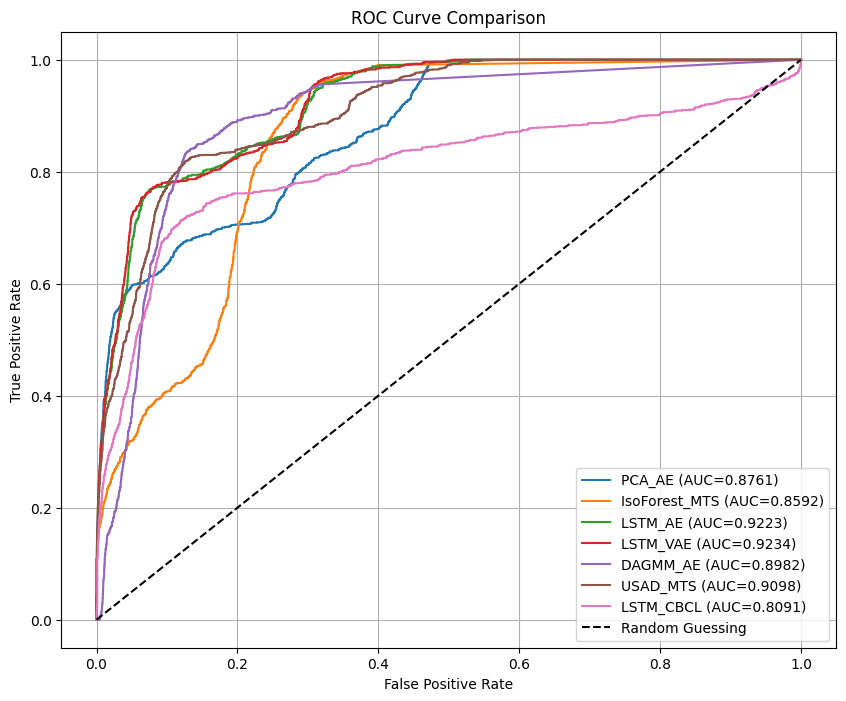

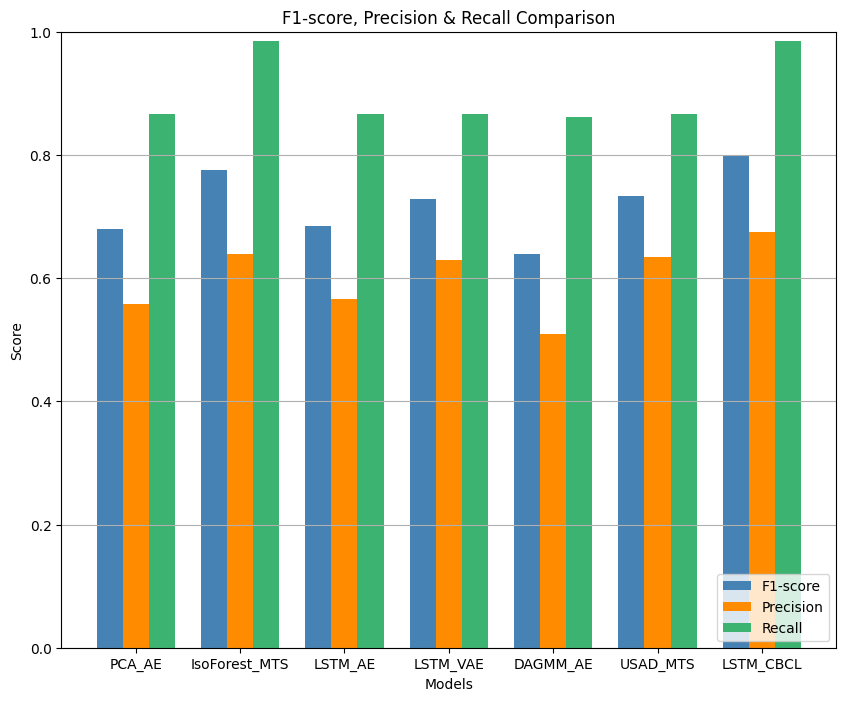

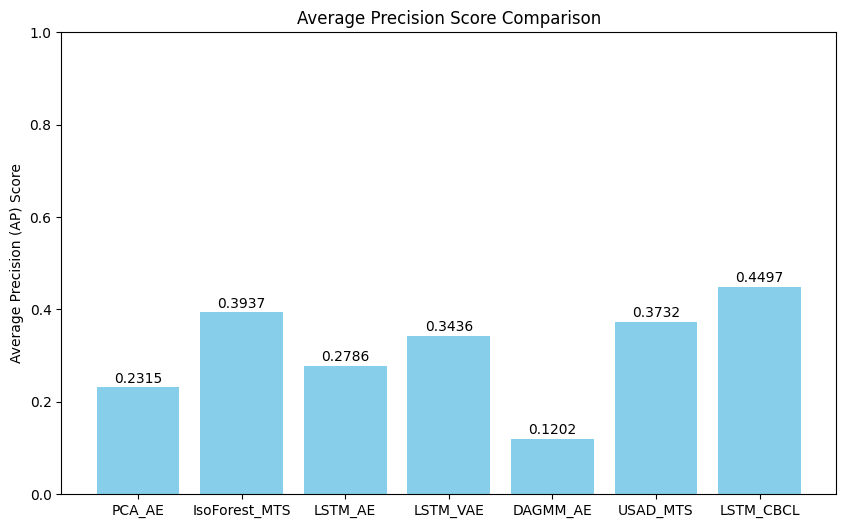

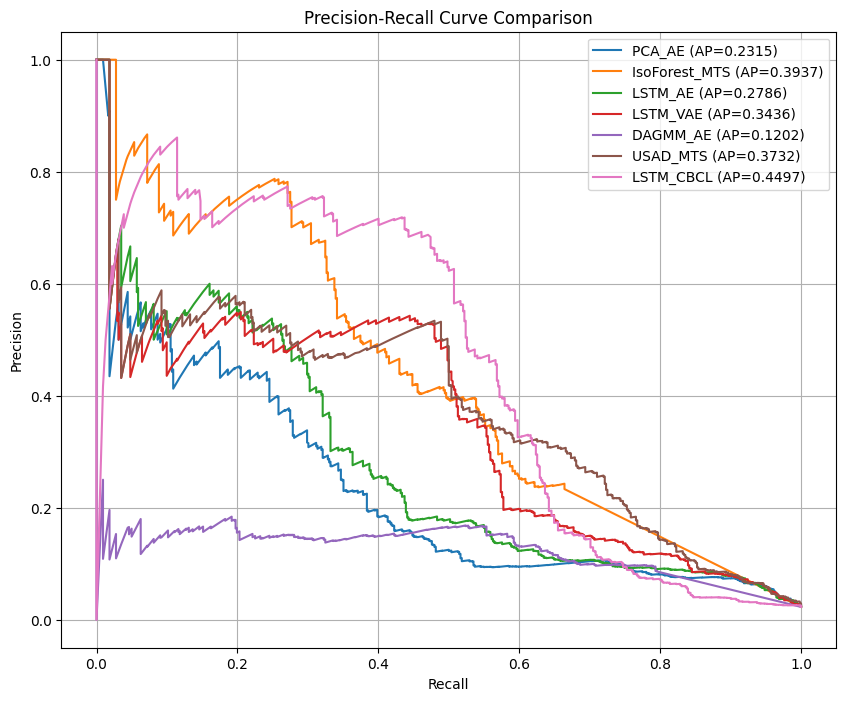

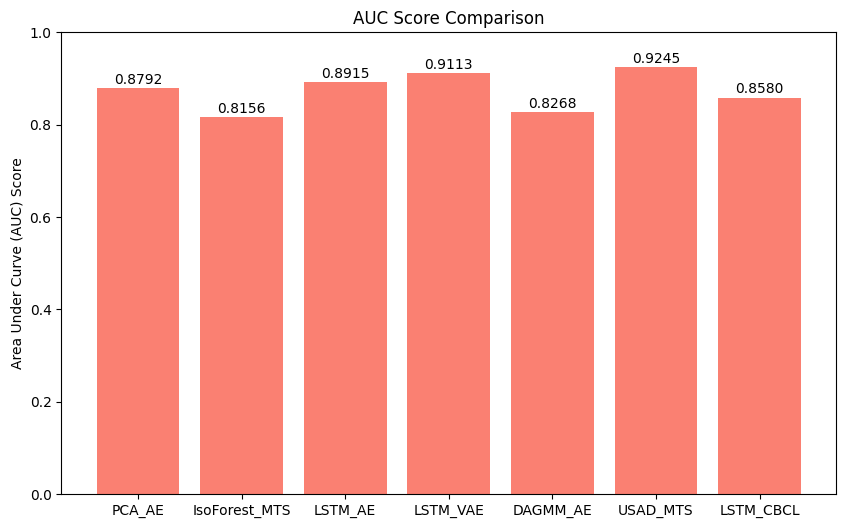

	 Server 1 - Machine 5
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 1.164755 - val_loss: 0.915727
	 Breakdown: 
	 MSE: 0.036353, Contrastive: 0.604652, Cluster: 0.250769, Hinge: 0.056643
Epoch 2/100 - train_loss: 0.949536 - val_loss: 0.905098
	 Breakdown: 
	 MSE: 0.033382, Contrastive: 0.605565, Cluster: 0.144320, Hinge: 0.084291
Epoch 3/100 - train_loss: 0.904310 - val_loss: 0.890935
	 Breakdown: 
	 MSE: 0.030775, Contrastive: 0.602560, Cluster: 0.112834, Hinge: 0.098748
Epoch 4/100 - train_loss: 0.884793 - val_loss: 0.872566
	 Breakdown: 
	 MSE: 0.027250, Contrastive: 0.598600, Cluster: 0.096568, Hinge: 0.106025
Epoch 5/100 - train_loss: 0.870386 - val_loss: 0.853900
	 Breakdown: 
	 MSE: 0.021681, Contrastive: 0.595738, Cluster: 0.087003, Hinge: 0.114551
Epoch 6/100 - train_loss: 0.857713 - val_loss: 0.837351
	 Breakdown: 
	 MSE: 0.019294, Contrastive: 0.589477, Cluster: 0.085347, Hinge: 0.114595
Epoch 7/100 - train_loss: 0.847237 - val_loss: 0.824840
	 Breakdown: 
	 MSE: 0.017912

KeyboardInterrupt: 

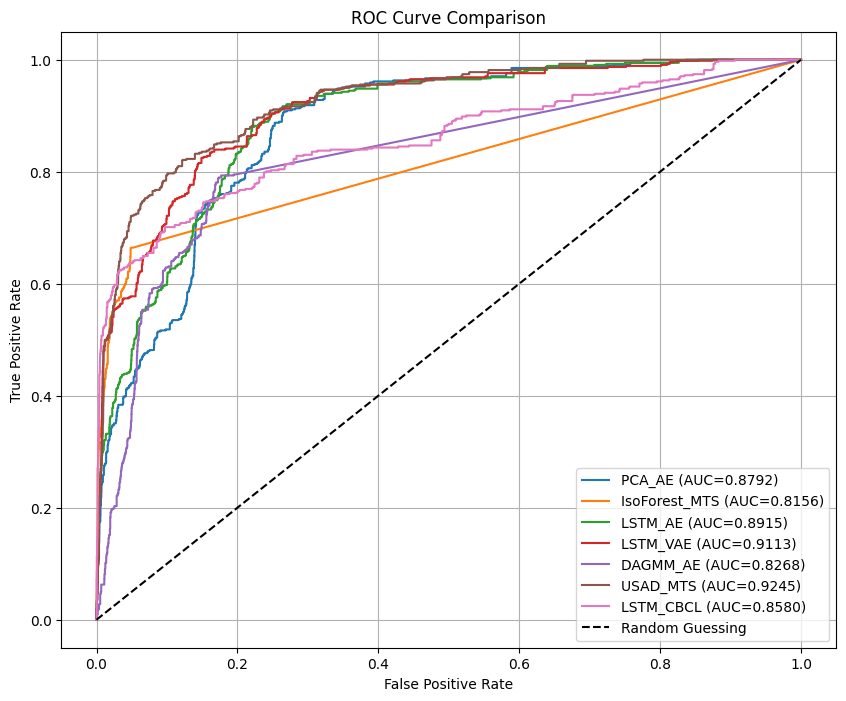

In [ ]:
tf.keras.backend.clear_session() 
""" run_results(use_timestamp_level=False, use_point_adjust=False, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Window_score', dirs_exist_ok=True)
tf.keras.backend.clear_session()

run_results(use_timestamp_level=True, use_point_adjust=False, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Timestamp Score', dirs_exist_ok=True)
tf.keras.backend.clear_session() """

run_results(use_timestamp_level=True, use_point_adjust=True, verbose=1, run_SMD=True, run_PSM=False, run_SMAP_MSL=False, run_WADI=False)
shutil.copytree('Model Comparisons', 'Model Comparisons - Point Adjusted', dirs_exist_ok=True)

In [ ]:
run_results(use_timestamp_level=True, use_point_adjust=True, verbose=1, run_SMD=False, run_PSM=False, run_SMAP_MSL=True, run_WADI=False)
shutil.copytree('Model Comparisons', 'Model Comparisons - Point Adjusted', dirs_exist_ok=True)

new_f1s, new_rocs = extra_model_results(use_timestamp_level=True, use_point_adjust=True, verbose=1)
compare_existing_scores(dir='Model Comparisons - Point Adjusted/Dataset Performance/', new_f1s=new_f1s, new_rocs=new_rocs)